### EV Charging Stations in Nairobi

Updated Code with Service Providers distinguished. It is not an exhaustive list of service providers in Nairobi but it is a good place to start from. The code:

* Has a Map with bus routes following real roads
* Charging stations with operators labeled
* Interactive tooltips for better user experience

You can run the whole code in the next cell but explanation for each part of the code has been provided in the cells that follow.

In [1]:
import pandas as pd
import geopandas as gpd
import folium
import osmnx as ox
from shapely.geometry import LineString, MultiLineString

# Load BasiGo Bus Route Data
routes_data = {
    "Route": [
        "CBD - Allsops - JKIA", "CBD - Buruburu - Dandora", "CBD - Jogoo Road - Buruburu",
        "CBD - Jacaranda - Nyayo", "CBD - Kikuyu - Kitengela", "Utawala - Upperhill - Kiambu",
        "CBD - Kasarani - Mwiki", "CBD - Thika Road - Ruiru", "CBD - Lang'ata - Ongata Rongai",
        "CBD - South C - Mombasa Road", "CBD - Westlands - Lavington", "CBD - Karen - Ngong"
    ],
    "Operator": [
        "Citi Hoppa", "East Shuttle", "OMA Services", "Embassava", "Super Metro", "Metro Trans",
        "KBS", "Joy Shuttle", "City Hoppa", "Express Connections", "Metro Shuttle", "Super Metro"
    ]
}

routes_df = pd.DataFrame(routes_data)

# Comprehensive EV Charging Stations in Nairobi
charging_stations = {
    "Station": [
        "Embakasi Depot", "Kikuyu Depot", "Buruburu Charging", "Ruiru Charging", "Westlands Charging",
        "Total Energies EV Station", "KenGen EV Station", "Drive Electric Nairobi", "ChargeNet Kenya", "EVPower Nairobi",
        "Stima EV Nairobi", "Greenspark EV Hub", "Volt Kenya Charging", "EcoCharge Nairobi", "Juja EV Charging Hub"
    ],
    "Latitude": [-1.3235, -1.2486, -1.3000, -1.1456, -1.2663, -1.2921, -1.2811, -1.3005, -1.2715, -1.3245,
                 -1.2890, -1.2789, -1.3056, -1.2618, -1.1803],
    "Longitude": [36.9395, 36.6677, 36.8526, 36.9802, 36.8053, 36.8219, 36.8258, 36.7910, 36.8865, 36.8135,
                   36.8215, 36.8010, 36.8452, 36.8940, 36.9582],
    "Operator": [
        "BasiGo", "NopeaRide", "BasiGo", "Opibus", "NopeaRide",
        "Total Energies", "KenGen", "Drive Electric", "ChargeNet", "EVPower",
        "Stima EV", "Greenspark", "Volt Kenya", "EcoCharge", "Juja EV"
    ]
}
charging_df = pd.DataFrame(charging_stations)
charging_gdf = gpd.GeoDataFrame(charging_df, geometry=gpd.points_from_xy(charging_df.Longitude, charging_df.Latitude), crs="EPSG:4326")

# Generate Routes on Actual Roads
G = ox.graph_from_place("Nairobi, Kenya", network_type='drive')
endpoints = [
    ((-1.2864, 36.8172), (-1.3192, 36.9275)), ((-1.2864, 36.8172), (-1.2791, 36.8993)),
    ((-1.2864, 36.8172), (-1.2898, 36.8572)), ((-1.2864, 36.8172), (-1.3070, 36.8521)),
    ((-1.2864, 36.8172), (-1.2471, 36.6673)), ((-1.2864, 36.8172), (-1.2245, 36.8365)),
    ((-1.2864, 36.8172), (-1.2173, 36.8985)), ((-1.2864, 36.8172), (-1.1435, 37.0132)),
    ((-1.2864, 36.8172), (-1.3958, 36.6963)), ((-1.2864, 36.8172), (-1.3309, 36.8608)),
    ((-1.2864, 36.8172), (-1.2836, 36.7834)), ((-1.2864, 36.8172), (-1.3125, 36.6749))
]
routes_lines = []
for start, end in endpoints:
    orig = ox.distance.nearest_nodes(G, start[1], start[0])
    dest = ox.distance.nearest_nodes(G, end[1], end[0])
    route = ox.shortest_path(G, orig, dest, weight='length')
    edges = ox.graph_to_gdfs(G.subgraph(route), nodes=False)
    route_geom = MultiLineString(edges.geometry.values)
    routes_lines.append(route_geom)

routes_gdf = gpd.GeoDataFrame({'Route': routes_data['Route'], 'Operator': routes_data['Operator'], 'geometry': routes_lines}, crs="EPSG:4326")

# Folium Map with Provider Distinction
m = folium.Map(location=[-1.286389, 36.817223], zoom_start=12)
colors = {"BasiGo": "blue", "NopeaRide": "green", "Opibus": "purple", "Total Energies": "orange", "KenGen": "red",
          "Drive Electric": "pink", "ChargeNet": "darkblue", "EVPower": "cadetblue", "Stima EV": "lightgreen", "Greenspark": "darkgreen", 
          "Volt Kenya": "darkred", "EcoCharge": "lightblue", "Juja EV": "gray"}

for _, row in routes_gdf.iterrows():
    for line in row['geometry'].geoms:
        folium.PolyLine([(lat, lon) for lon, lat in line.coords], color="red", weight=2.5, tooltip=f"{row['Route']} ({row['Operator']})").add_to(m)

for _, row in charging_gdf.iterrows():
    color = colors.get(row['Operator'], "blue")
    folium.Marker(
        [row["Latitude"], row["Longitude"]], 
        tooltip=f"{row['Station']} - {row['Operator']}", 
        popup=f"{row['Station']} - {row['Operator']}", 
        icon=folium.Icon(color=color, icon="bolt", prefix="fa")
    ).add_to(m)

display(routes_df)
m


,Route,Operator
0,CBD - Allsops - JKIA,Citi Hoppa
1,CBD - Buruburu - Dandora,East Shuttle
2,CBD - Jogoo Road - Buruburu,OMA Services
3,CBD - Jacaranda - Nyayo,Embassava
4,CBD - Kikuyu - Kitengela,Super Metro
5,Utawala - Upperhill - Kiambu,Metro Trans
6,CBD - Kasarani - Mwiki,KBS
7,CBD - Thika Road - Ruiru,Joy Shuttle
8,CBD - Lang'ata - Ongata Rongai,City Hoppa
9,CBD - South C - Mombasa Road,Express Connections


In [45]:
charging_df

,Station,Latitude,Longitude,Operator
0,Embakasi Depot,-1.3235,36.9395,BasiGo
1,Kikuyu Depot,-1.2486,36.6677,NopeaRide
2,Buruburu Charging,-1.3000,36.8526,BasiGo
3,Ruiru Charging,-1.1456,36.9802,Opibus
4,Westlands Charging,-1.2663,36.8053,NopeaRide
5,Total Energies EV Station,-1.2921,36.8219,Total Energies
6,KenGen EV Station,-1.2811,36.8258,KenGen
7,Drive Electric Nairobi,-1.3005,36.7910,Drive Electric
8,ChargeNet Kenya,-1.2715,36.8865,ChargeNet
9,EVPower Nairobi,-1.3245,36.8135,EVPower


### 1. mport Necessary Libraries

In [2]:
import pandas as pd
import geopandas as gpd
import folium
import osmnx as ox
from shapely.geometry import LineString, MultiLineString

### 2. Define BasiGo Bus Routes

Store BasiGo bus routes and their operators in a pandas DataFrame.

In [3]:
routes_data = {
    "Route": [
        "CBD - Allsops - JKIA", "CBD - Buruburu - Dandora", "CBD - Jogoo Road - Buruburu",
        "CBD - Jacaranda - Nyayo", "CBD - Kikuyu - Kitengela", "Utawala - Upperhill - Kiambu",
        "CBD - Kasarani - Mwiki", "CBD - Thika Road - Ruiru", "CBD - Lang'ata - Ongata Rongai",
        "CBD - South C - Mombasa Road", "CBD - Westlands - Lavington", "CBD - Karen - Ngong"
    ],
    "Operator": [
        "Citi Hoppa", "East Shuttle", "OMA Services", "Embassava", "Super Metro", "Metro Trans",
        "KBS", "Joy Shuttle", "City Hoppa", "Express Connections", "Metro Shuttle", "Super Metro"
    ]
}
routes_df = pd.DataFrame(routes_data)
routes_df

,Route,Operator
0,CBD - Allsops - JKIA,Citi Hoppa
1,CBD - Buruburu - Dandora,East Shuttle
2,CBD - Jogoo Road - Buruburu,OMA Services
3,CBD - Jacaranda - Nyayo,Embassava
4,CBD - Kikuyu - Kitengela,Super Metro
5,Utawala - Upperhill - Kiambu,Metro Trans
6,CBD - Kasarani - Mwiki,KBS
7,CBD - Thika Road - Ruiru,Joy Shuttle
8,CBD - Lang'ata - Ongata Rongai,City Hoppa
9,CBD - South C - Mombasa Road,Express Connections


### 3. Define EV Charging Stations

In [4]:
charging_stations = {
    "Station": [
        "Embakasi Depot", "Kikuyu Depot", "Buruburu Charging", "Ruiru Charging", "Westlands Charging",
        "Total Energies EV Station", "KenGen EV Station", "Drive Electric Nairobi", "ChargeNet Kenya", "EVPower Nairobi",
        "Stima EV Nairobi", "Greenspark EV Hub", "Volt Kenya Charging", "EcoCharge Nairobi", "Juja EV Charging Hub"
    ],
    "Latitude": [-1.3235, -1.2486, -1.3000, -1.1456, -1.2663, -1.2921, -1.2811, -1.3005, -1.2715, -1.3245,
                 -1.2890, -1.2789, -1.3056, -1.2618, -1.1803],
    "Longitude": [36.9395, 36.6677, 36.8526, 36.9802, 36.8053, 36.8219, 36.8258, 36.7910, 36.8865, 36.8135,
                   36.8215, 36.8010, 36.8452, 36.8940, 36.9582],
    "Operator": [
        "BasiGo", "NopeaRide", "BasiGo", "Opibus", "NopeaRide",
        "Total Energies", "KenGen", "Drive Electric", "ChargeNet", "EVPower",
        "Stima EV", "Greenspark", "Volt Kenya", "EcoCharge", "Juja EV"
    ]
}


Stores EV charging station names, coordinates, and operators in a dictionary and convert it into a GeoPandas GeoDataFrame for mapping.

In [5]:
charging_df = pd.DataFrame(charging_stations)
charging_gdf = gpd.GeoDataFrame(charging_df, geometry=gpd.points_from_xy(charging_df.Longitude, charging_df.Latitude), crs="EPSG:4326")


In [6]:
charging_df

,Station,Latitude,Longitude,Operator
0,Embakasi Depot,-1.3235,36.9395,BasiGo
1,Kikuyu Depot,-1.2486,36.6677,NopeaRide
2,Buruburu Charging,-1.3000,36.8526,BasiGo
3,Ruiru Charging,-1.1456,36.9802,Opibus
4,Westlands Charging,-1.2663,36.8053,NopeaRide
5,Total Energies EV Station,-1.2921,36.8219,Total Energies
6,KenGen EV Station,-1.2811,36.8258,KenGen
7,Drive Electric Nairobi,-1.3005,36.7910,Drive Electric
8,ChargeNet Kenya,-1.2715,36.8865,ChargeNet
9,EVPower Nairobi,-1.3245,36.8135,EVPower


In [7]:
charging_gdf

,Station,Latitude,Longitude,Operator,geometry
0,Embakasi Depot,-1.3235,36.9395,BasiGo,POINT (36.93950 -1.32350)
1,Kikuyu Depot,-1.2486,36.6677,NopeaRide,POINT (36.66770 -1.24860)
2,Buruburu Charging,-1.3000,36.8526,BasiGo,POINT (36.85260 -1.30000)
3,Ruiru Charging,-1.1456,36.9802,Opibus,POINT (36.98020 -1.14560)
4,Westlands Charging,-1.2663,36.8053,NopeaRide,POINT (36.80530 -1.26630)
5,Total Energies EV Station,-1.2921,36.8219,Total Energies,POINT (36.82190 -1.29210)
6,KenGen EV Station,-1.2811,36.8258,KenGen,POINT (36.82580 -1.28110)
7,Drive Electric Nairobi,-1.3005,36.7910,Drive Electric,POINT (36.79100 -1.30050)
8,ChargeNet Kenya,-1.2715,36.8865,ChargeNet,POINT (36.88650 -1.27150)
9,EVPower Nairobi,-1.3245,36.8135,EVPower,POINT (36.81350 -1.32450)


### 4. Generate Routes Using Road Network 

* Downloads Nairobi's road network for routing.
* The parameter network_type='drive' ensures only drivable roads are included.

In [8]:
G = ox.graph_from_place("Nairobi, Kenya", network_type='drive')

Define start and end points for each bus route using real-world GPS coordinates.

In [9]:
endpoints = [
    ((-1.2864, 36.8172), (-1.3192, 36.9275)), ((-1.2864, 36.8172), (-1.2791, 36.8993)),
    ((-1.2864, 36.8172), (-1.2898, 36.8572)), ((-1.2864, 36.8172), (-1.3070, 36.8521)),
    ((-1.2864, 36.8172), (-1.2471, 36.6673)), ((-1.2864, 36.8172), (-1.2245, 36.8365)),
    ((-1.2864, 36.8172), (-1.2173, 36.8985)), ((-1.2864, 36.8172), (-1.1435, 37.0132)),
    ((-1.2864, 36.8172), (-1.3958, 36.6963)), ((-1.2864, 36.8172), (-1.3309, 36.8608)),
    ((-1.2864, 36.8172), (-1.2836, 36.7834)), ((-1.2864, 36.8172), (-1.3125, 36.6749))
]


Find the nearest nodes in the road network for each start and end location and then calculate the shortest path using OpenStreetMap data.
Converts the path to a MultiLineString for mapping.

In [10]:
routes_lines = []
for start, end in endpoints:
    orig = ox.distance.nearest_nodes(G, start[1], start[0])
    dest = ox.distance.nearest_nodes(G, end[1], end[0])
    route = ox.shortest_path(G, orig, dest, weight='length')
    edges = ox.graph_to_gdfs(G.subgraph(route), nodes=False)
    route_geom = MultiLineString(edges.geometry.values)
    routes_lines.append(route_geom)


Convert the bus routes into a GeoDataFrame for visualization.

In [11]:
routes_gdf = gpd.GeoDataFrame({'Route': routes_data['Route'], 'Operator': routes_data['Operator'], 'geometry': routes_lines}, crs="EPSG:4326")

In [12]:
routes_gdf

,Route,Operator,geometry
0,CBD - Allsops - JKIA,Citi Hoppa,"MULTILINESTRING ((36.83784 -1.31916, 36.83805 ..."
1,CBD - Buruburu - Dandora,East Shuttle,"MULTILINESTRING ((36.82889 -1.28844, 36.82914 ..."
2,CBD - Jogoo Road - Buruburu,OMA Services,"MULTILINESTRING ((36.82678 -1.28772, 36.82694 ..."
3,CBD - Jacaranda - Nyayo,Embassava,"MULTILINESTRING ((36.81759 -1.28651, 36.81758 ..."
4,CBD - Kikuyu - Kitengela,Super Metro,"MULTILINESTRING ((36.76229 -1.28968, 36.76234 ..."
5,Utawala - Upperhill - Kiambu,Metro Trans,"MULTILINESTRING ((36.84233 -1.23121, 36.84185 ..."
6,CBD - Kasarani - Mwiki,KBS,"MULTILINESTRING ((36.88919 -1.22180, 36.88973 ..."
7,CBD - Thika Road - Ruiru,Joy Shuttle,"MULTILINESTRING ((36.88919 -1.22180, 36.88964 ..."
8,CBD - Lang'ata - Ongata Rongai,City Hoppa,"MULTILINESTRING ((36.73670 -1.35520, 36.73585 ..."
9,CBD - South C - Mombasa Road,Express Connections,"MULTILINESTRING ((36.83784 -1.31916, 36.83805 ..."


Generate the Interactive Folium Map centered in Nairobi.

In [13]:
m = folium.Map(location=[-1.286389, 36.817223], zoom_start=12)

Draws the bus routes on the map using red lines.

In [14]:
for _, row in routes_gdf.iterrows():
    for line in row['geometry'].geoms:
        folium.PolyLine([(lat, lon) for lon, lat in line.coords], color="red", weight=2.5, tooltip=f"{row['Route']} ({row['Operator']})").add_to(m)


Add EV charging stations to the map with icons color-coded by provider.

In [15]:
for _, row in charging_gdf.iterrows():
    color = colors.get(row['Operator'], "blue")
    folium.Marker(
        [row["Latitude"], row["Longitude"]], 
        tooltip=f"{row['Station']} - {row['Operator']}", 
        popup=f"{row['Station']} - {row['Operator']}", 
        icon=folium.Icon(color=color, icon="bolt", prefix="fa")
    ).add_to(m)


Display the interactive map

In [16]:
m

In [17]:
charging_df

,Station,Latitude,Longitude,Operator
0,Embakasi Depot,-1.3235,36.9395,BasiGo
1,Kikuyu Depot,-1.2486,36.6677,NopeaRide
2,Buruburu Charging,-1.3000,36.8526,BasiGo
3,Ruiru Charging,-1.1456,36.9802,Opibus
4,Westlands Charging,-1.2663,36.8053,NopeaRide
5,Total Energies EV Station,-1.2921,36.8219,Total Energies
6,KenGen EV Station,-1.2811,36.8258,KenGen
7,Drive Electric Nairobi,-1.3005,36.7910,Drive Electric
8,ChargeNet Kenya,-1.2715,36.8865,ChargeNet
9,EVPower Nairobi,-1.3245,36.8135,EVPower


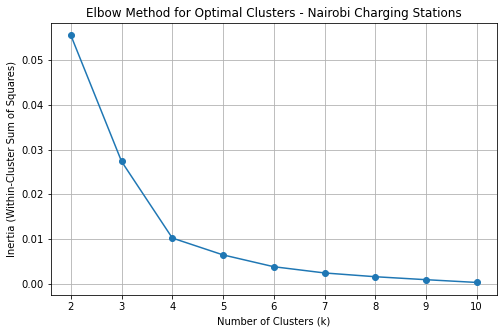

In [23]:
# Re-import necessary libraries
import geopandas as gpd

from sklearn.cluster import KMeans

import matplotlib.pyplot as plt



# Convert to GeoDataFrame
charging_gdf = gpd.GeoDataFrame(charging_df, geometry=gpd.points_from_xy(charging_df.Longitude, charging_df.Latitude), crs="EPSG:4326")

# Extract latitude and longitude for clustering
nairobi_locations = charging_gdf[["Longitude", "Latitude"]]

# Determine the optimal number of clusters using the Elbow method
inertia = []
K_range = range(2, 11)  # Testing cluster sizes from 2 to 7

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(nairobi_locations)
    inertia.append(kmeans.inertia_)

# Plot the Elbow curve to determine the best k
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Optimal Clusters - Nairobi Charging Stations")
plt.grid(True)
plt.show()


In [27]:
# Selecting the optimal number of clusters based on the elbow method (let's assume k=4 for now)
optimal_k = 5

# Apply K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
charging_gdf["cluster"] = kmeans.fit_predict(nairobi_locations)

# Visualize the clustered charging stations on a map
import folium

# Create a Folium map centered around Nairobi
m = folium.Map(location=[-1.286389, 36.817223], zoom_start=12)

# Define colors for clusters
cluster_colors = ["red", "blue", "green", "purple", "orange", "brown", "pink"]

# Add charging stations to the map with cluster coloring
for _, row in charging_gdf.iterrows():
    folium.Marker(
        [row["Latitude"], row["Longitude"]],
        tooltip=f"{row['Station']} - Cluster {row['cluster']}",
        popup=f"{row['Station']} - Operator: {row['Operator']}",
        icon=folium.Icon(color=cluster_colors[row["cluster"] % len(cluster_colors)], icon="bolt", prefix="fa")
    ).add_to(m)

# Display the interactive map
m


### Using Google Maps API

In [20]:
import googlemaps

# Set up API Key
API_KEY = "I will share"
gmaps = googlemaps.Client(key=API_KEY)

# Define coordinates
location = (-1.286389, 36.817223)  # Nairobi CBD

# Get the nearest road segment
response = gmaps.nearest_roads([location])
print(response)

[{'location': {'latitude': -1.286388227164223, 'longitude': 36.81722456407105}, 'originalIndex': 0, 'placeId': 'ChIJRQidl9EQLxgRYDdHunTru6o'}]


#### Fetching EV Charging Stations Using Google Maps API

In [8]:
import requests
import pandas as pd

# Google Maps API Key
API_KEY = API_KEY

# Define Nairobi Coordinates & Search Query
location = "-1.286389,36.817223"  # Nairobi Center
radius = 40000  # Search within 40km
query = "EV charging station"

# Google Places API Request
url = f"https://maps.googleapis.com/maps/api/place/nearbysearch/json?location={location}&radius={radius}&keyword={query}&key={API_KEY}"
response = requests.get(url).json()

# Extract Data
places = []
for place in response.get("results", []):
    places.append({
        "Name": place.get("name"),
        "Latitude": place["geometry"]["location"]["lat"],
        "Longitude": place["geometry"]["location"]["lng"],
        "Address": place.get("vicinity"),
        "Rating": place.get("rating", "N/A"),
        "User Ratings": place.get("user_ratings_total", "N/A"),
        "Place ID": place.get("place_id")
    })

# Convert to DataFrame
ev_google_df = pd.DataFrame(places)

# Display Results
ev_google_df


,Name,Latitude,Longitude,Address,Rating,User Ratings,Place ID
0,BasiGo Charging Station,-1.278185,36.873188,Nairobi,4.2,5,ChIJr-a_lD8VLxgRtWfEgnhCOmA
1,Electric Vehicle Charging Station,-1.299806,36.794981,"PQ2V+3XH, Ngong Rd, Nairobi",5.0,1,ChIJ2WuIQCwRLxgRRcmgj8RQ4HE
2,BasiGo Charging Station,-1.283523,36.733083,"PP8M+H6W, Nairobi",0.0,0,ChIJx1_CNAAbLxgRcNbTddKTLpA
3,Electric Vehicle Charging Station,-1.329837,36.714577,"MPC7+3R8, Langata Rd, Nairobi",4.0,6,ChIJWb6CLIwbLxgRUIGF10_Ep_c
4,EVChaja Charging Station,-1.210779,36.794627,"QQQV+MVJ, Limuru Rd, Nairobi",5.0,1,ChIJ_UZcdPs9LxgRny7PVgC9cL0
5,Roam Hub - Lusaka,-1.301325,36.832909,"Total Energies, Lusaka Rd, Nairobi",4.3,17,ChIJTwVS7gARLxgRuAE_0KQMvs8
6,Roam Hub - Wayaki Way,-1.258721,36.781323,"Waiyaki Wy, Nairobi",5.0,1,ChIJTz9iImUZLxgR_zJglYTMuJY
7,BasiGo Depot - Embakasi,-1.329336,36.893101,"MVCV+PJ, Nairobi",5.0,3,ChIJteYEV2kTLxgR90K-Xv67c2c
8,Ecotrify,-1.289189,36.793277,"Mpuuga Gardens, Hurlingham Court, Rose Ave, Na...",0.0,0,ChIJIduyaMgRLxgRmcLgXYPwzvM
9,SupaChaja Charging Station,-1.186758,36.997345,Ruiru,4.0,2,ChIJXy8RCoVBLxgRRKUmWyPEFos


### Fetching Traffic Data for EV Stations

In [9]:
import time

# Get Traffic Data for Each Station
traffic_data = []

for _, row in ev_google_df.iterrows():
    lat, lon = row["Latitude"], row["Longitude"]
    
    traffic_url = f"https://maps.googleapis.com/maps/api/distancematrix/json?origins={lat},{lon}&destinations={lat},{lon}&departure_time=now&key={API_KEY}"
    response = requests.get(traffic_url).json()
    
    # Check if "rows" exist and contains elements
    if "rows" in response and response["rows"]:
        if "elements" in response["rows"][0] and response["rows"][0]["elements"]:
            element = response["rows"][0]["elements"][0]
            traffic_status = element.get("status", "No Data")
            duration_traffic = element.get("duration_in_traffic", {}).get("text", "N/A")
        else:
            traffic_status = "No Data"
            duration_traffic = "N/A"
    else:
        traffic_status = "No Data"
        duration_traffic = "N/A"

    traffic_data.append({
        "Name": row["Name"],
        "Traffic_Status": traffic_status,
        "Duration_Traffic": duration_traffic
    })
    
    # Avoid hitting API rate limits
    time.sleep(1)

# Convert to DataFrame
traffic_df = pd.DataFrame(traffic_data)

# Display Traffic Data
traffic_df


,Name,Traffic_Status,Duration_Traffic
0,BasiGo Charging Station,No Data,N/A
1,Electric Vehicle Charging Station,No Data,N/A
2,BasiGo Charging Station,No Data,N/A
3,Electric Vehicle Charging Station,No Data,N/A
4,EVChaja Charging Station,No Data,N/A
5,Roam Hub - Lusaka,No Data,N/A
6,Roam Hub - Wayaki Way,No Data,N/A
7,BasiGo Depot - Embakasi,No Data,N/A
8,Ecotrify,No Data,N/A
9,SupaChaja Charging Station,No Data,N/A


The code above does not seem to work because Google Maps Times Out

### Code to Fetch Nearby Places for Population Density

- Use Google Places API to check residential areas, malls, supermarkets, and offices near each station.
- High population density areas may need more charging infrastructure.

In [49]:
nearby_data = []

for _, row in ev_google_df.iterrows():
    lat, lon = row["Latitude"], row["Longitude"]
    
    # Define place categories (e.g., supermarkets, malls, offices)
    place_types = ["supermarket", "shopping_mall", "residential", "office"]
    
    for place_type in place_types:
        places_url = f"https://maps.googleapis.com/maps/api/place/nearbysearch/json?location={lat},{lon}&radius=500&keyword={place_type}&key={API_KEY}"
        response = requests.get(places_url).json()
        
        if "results" in response:
            nearby_data.append({
                "EV_Station": row["Name"],
                "Nearby_Place_Type": place_type,
                "Nearby_Place_Count": len(response["results"])
            })

# Convert to DataFrame
nearby_df = pd.DataFrame(nearby_data)

nearby_df.head(20)


,EV_Station,Nearby_Place_Type,Nearby_Place_Count
0,BasiGo Charging Station,supermarket,6
1,BasiGo Charging Station,shopping_mall,3
2,BasiGo Charging Station,residential,0
3,BasiGo Charging Station,office,1
4,Electric Vehicle Charging Station,supermarket,7
5,Electric Vehicle Charging Station,shopping_mall,3
6,Electric Vehicle Charging Station,residential,12
7,Electric Vehicle Charging Station,office,4
8,BasiGo Charging Station,supermarket,7
9,BasiGo Charging Station,shopping_mall,4


### 5 Strategic EV Placement Areas and 10 Areas that they can be placed because they are underserved

In [62]:
import googlemaps
import pandas as pd
import geopandas as gpd
import folium
import osmnx as ox
import numpy as np
from shapely.geometry import MultiLineString
from sklearn.cluster import KMeans
import random

# Replace with your Google API Key
API_KEY = API_KEY
gmaps = googlemaps.Client(key=API_KEY)

# ================================
# Fetch EV Charging Stations from Google Maps
# ================================
def get_charging_stations(location=(-1.286389, 36.817223), radius=30000):
    places_result = gmaps.places_nearby(
        location=location,
        radius=radius,
        keyword="EV charging station",
        type="point_of_interest"
    )
    
    stations = []
    for place in places_result.get("results", []):
        stations.append({
            "Station": place["name"],
            "Latitude": place["geometry"]["location"]["lat"],
            "Longitude": place["geometry"]["location"]["lng"],
            "Rating": place.get("rating", "N/A"),
            "Address": place.get("vicinity", "N/A")
        })
    
    return pd.DataFrame(stations)

charging_df = get_charging_stations()

# Distinguish Providers and Assign Colors
provider_colors = {}
unique_providers = charging_df["Station"].apply(lambda x: x.split()[0] if " " in x else "Unknown").unique()
colors = ["blue", "green", "red", "purple", "orange", "darkblue", "darkred", "cadetblue", "lightblue", "darkgreen"]
random.shuffle(colors)
for i, provider in enumerate(unique_providers):
    provider_colors[provider] = colors[i % len(colors)]

charging_df["Provider"] = charging_df["Station"].apply(lambda x: x.split()[0] if " " in x else "Unknown")

# ================================
# Load BasiGo Bus Route Data
# ================================
routes_data = {
    "Route": [
        "CBD - Allsops - JKIA", "CBD - Buruburu - Dandora", "CBD - Jogoo Road - Buruburu",
        "CBD - Jacaranda - Nyayo", "CBD - Kikuyu - Kitengela", "Utawala - Upperhill - Kiambu",
        "CBD - Kasarani - Mwiki", "CBD - Thika Road - Ruiru", "CBD - Lang'ata - Ongata Rongai",
        "CBD - South C - Mombasa Road", "CBD - Westlands - Lavington", "CBD - Karen - Ngong"
    ],
    "Operator": [
        "Citi Hoppa", "East Shuttle", "OMA Services", "Embassava", "Super Metro", "Metro Trans",
        "KBS", "Joy Shuttle", "City Hoppa", "Express Connections", "Metro Shuttle", "Super Metro"
    ]
}

routes_df = pd.DataFrame(routes_data)

# ================================
# Generate BasiGo Bus Routes
# ================================
G = ox.graph_from_place("Nairobi, Kenya", network_type='drive')
endpoints = [
    ((-1.2864, 36.8172), (-1.3192, 36.9275)), ((-1.2864, 36.8172), (-1.2791, 36.8993)),
    ((-1.2864, 36.8172), (-1.2898, 36.8572)), ((-1.2864, 36.8172), (-1.3070, 36.8521)),
    ((-1.2864, 36.8172), (-1.2471, 36.6673)), ((-1.2864, 36.8172), (-1.2245, 36.8365)),
    ((-1.2864, 36.8172), (-1.2173, 36.8985)), ((-1.2864, 36.8172), (-1.1435, 37.0132)),
    ((-1.2864, 36.8172), (-1.3958, 36.6963)), ((-1.2864, 36.8172), (-1.3309, 36.8608)),
    ((-1.2864, 36.8172), (-1.2836, 36.7834)), ((-1.2864, 36.8172), (-1.3125, 36.6749))
]

routes_lines = []
for start, end in endpoints:
    orig = ox.distance.nearest_nodes(G, start[1], start[0])
    dest = ox.distance.nearest_nodes(G, end[1], end[0])
    route = ox.shortest_path(G, orig, dest, weight='length')
    edges = ox.graph_to_gdfs(G.subgraph(route), nodes=False)
    route_geom = MultiLineString(edges.geometry.values)
    routes_lines.append(route_geom)

routes_gdf = gpd.GeoDataFrame({'Route': routes_data['Route'], 'Operator': routes_data['Operator'], 'geometry': routes_lines}, crs="EPSG:4326")

# ================================
# Suggest New Charging Locations (Away from Centroids)
# ================================
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(charging_df[["Latitude", "Longitude"]])
new_station_locations = kmeans.cluster_centers_ + (np.random.rand(*kmeans.cluster_centers_.shape) - 0.5) * 0.05

# ================================
# Generate Folium Map
# ================================
m = folium.Map(location=[-1.286389, 36.817223], zoom_start=12)

# Add Charging Stations
for _, row in charging_df.iterrows():
    folium.Marker(
        [row["Latitude"], row["Longitude"]],
        popup=f"{row['Station']} ({row['Provider']})",
        tooltip=row["Station"],
        icon=folium.Icon(color=provider_colors.get(row["Provider"], "gray"), icon="bolt", prefix="fa")
    ).add_to(m)

# Add Suggested Charging Stations
for lat, lon in new_station_locations:
    folium.Marker(
        [lat, lon],
        popup="Suggested Charging Station",
        icon=folium.Icon(color="orange", icon="bolt", prefix="fa")
    ).add_to(m)

# Add BasiGo Bus Routes
for _, row in routes_gdf.iterrows():
    for line in row['geometry'].geoms:
        folium.PolyLine([(lat, lon) for lon, lat in line.coords], color="red", weight=2.5, tooltip=f"{row['Route']} ({row['Operator']})").add_to(m)

# Save Results
charging_df.to_csv("nairobi_charging_stations.csv", index=False)

m


#### Suggested charging stations along access roads and highways by adjusting their locations using OSMNx nearest road nodes.

In [12]:
import googlemaps
import pandas as pd
import geopandas as gpd
import folium
import osmnx as ox
import numpy as np
from shapely.geometry import MultiLineString
from sklearn.cluster import KMeans, DBSCAN
import random

# Replace with your Google API Key
API_KEY = API_KEY
gmaps = googlemaps.Client(key=API_KEY)

# ================================
# Fetch EV Charging Stations from Google Maps
# ================================
def get_charging_stations(location=(-1.286389, 36.817223), radius=30000):
    places_result = gmaps.places_nearby(
        location=location,
        radius=radius,
        keyword="EV charging station",
        type="point_of_interest"
    )
    
    stations = []
    for place in places_result.get("results", []):
        stations.append({
            "Station": place["name"],
            "Latitude": place["geometry"]["location"]["lat"],
            "Longitude": place["geometry"]["location"]["lng"],
            "Rating": place.get("rating", "N/A"),
            "Address": place.get("vicinity", "N/A")
        })
    
    return pd.DataFrame(stations)

charging_df = get_charging_stations()

# ================================
# Fetch High-Traffic POIs (Including Public Parking, Petrol Stations, and Bus Terminals)
# ================================
def get_pois(location=(-1.286389, 36.817223), radius=30000):
    search_keywords = ["mall", "petrol station", "public parking", "bus terminal"]
    pois = []
    for keyword in search_keywords:
        places_result = gmaps.places_nearby(
            location=location,
            radius=radius,
            keyword=keyword,
            type="point_of_interest"
        )
        for place in places_result.get("results", []):
            pois.append({
                "Name": place["name"],
                "Type": keyword,
                "Latitude": place["geometry"]["location"]["lat"],
                "Longitude": place["geometry"]["location"]["lng"],
                "Rating": place.get("rating", "N/A"),
                "Address": place.get("vicinity", "N/A")
            })
    return pd.DataFrame(pois)

pois_df = get_pois()

# Distinguish Providers and Assign Unique Colors
unique_providers = charging_df["Station"].apply(lambda x: x.split()[0] if " " in x else "Unknown").unique()
color_palette = ["blue", "green", "red", "purple", "orange", "darkblue", "darkred", "cadetblue", "lightblue", "darkgreen"]
random.shuffle(color_palette)
provider_colors = {provider: color_palette[i % len(color_palette)] for i, provider in enumerate(unique_providers)}
charging_df["Provider"] = charging_df["Station"].apply(lambda x: x.split()[0] if " " in x else "Unknown")

# ================================
# Identify Underserved Areas & Place New Stations Along Roads/Highways
# ================================
charging_locations = charging_df[["Latitude", "Longitude"]].values
poi_locations = pois_df[["Latitude", "Longitude"]].values

# Use K-Means clustering to place new stations near POIs
num_new_stations = min(10, len(poi_locations))  # Limit the number of suggested stations
if num_new_stations > 0:
    kmeans = KMeans(n_clusters=num_new_stations, random_state=42, n_init=10)
    kmeans.fit(poi_locations)
    new_station_locations = kmeans.cluster_centers_
    
    # Adjust station locations to be along roads/highways using OSMNx
    G = ox.graph_from_place("Nairobi, Kenya", network_type='drive')
    adjusted_station_locations = []
    for lat, lon in new_station_locations:
        nearest_node = ox.distance.nearest_nodes(G, lon, lat)
        nearest_point = (G.nodes[nearest_node]['y'], G.nodes[nearest_node]['x'])
        adjusted_station_locations.append(nearest_point)
else:
    adjusted_station_locations = []

# ================================
# Generate Folium Map
# ================================
m = folium.Map(location=[-1.286389, 36.817223], zoom_start=12)

# Add Charging Stations with Provider Colors
for _, row in charging_df.iterrows():
    folium.Marker(
        [row["Latitude"], row["Longitude"]],
        popup=f"{row['Station']} ({row['Provider']})",
        tooltip=row["Station"],
        icon=folium.Icon(color=provider_colors.get(row["Provider"], "gray"), icon="bolt", prefix="fa")
    ).add_to(m)

# Add POIs
poi_colors = {"mall": "blue", "petrol station": "red", "public parking": "darkpurple", "bus terminal": "black"}
for _, row in pois_df.iterrows():
    folium.Marker(
        [row["Latitude"], row["Longitude"]],
        popup=f"{row['Name']} ({row['Type']})", 
        tooltip=row["Name"],
        icon=folium.Icon(color=poi_colors.get(row["Type"], "gray"), icon="info-sign")
    ).add_to(m)

# Add Suggested Charging Stations with Labels (Placed Along Roads/Highways)
for i, (lat, lon) in enumerate(adjusted_station_locations):
    folium.Marker(
        [lat, lon],
        popup=f"Suggested Charging Station {i+1} (Near High-Demand POI & Along Highway)",
        tooltip=f"New Charging Site {i+1}",
        icon=folium.Icon(color="orange", icon="bolt", prefix="fa")
    ).add_to(m)

# Save Results
charging_df.to_csv("nairobi_charging_stations.csv", index=False)
pois_df.to_csv("nairobi_pois_data.csv", index=False)

m
